# Análisis de Evolución de Perturbaciones en Gravedad Modificada

Este notebook analiza la evolución de las perturbaciones de densidad δ en modelos de gravedad modificada comparado con ΛCDM para diferentes condiciones iniciales.

## Objetivos:
- Comparar la evolución de δ entre MG y ΛCDM
- Estudiar el efecto de diferentes parámetros cosmológicos
- Analizar la tasa de crecimiento y ratios entre modelos

## 1. Librerías y config inicial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import sys
sys.path.append('/home/pedrorozin/scripts/python')
from delta_solver_mg_pedro import DeltaSolver

# Configuración para plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## 2. Función principal de comparación

In [5]:
def plot_delta_evolution_comparison(parameter_sets=None, num_points=1000, save_fig=False):
    """
    Plotea la evolución de delta para diferentes conjuntos de parámetros
    
    Parameters:
    -----------
    parameter_sets : list of dict or None
        Lista de diccionarios con parámetros [a, kh, h, Omega_m]
        Si es None, usa valores por defecto
    num_points : int
        Número de puntos para la integración
    save_fig : bool
        Si guardar la figura
    """
    
    # Parámetros por defecto si no se proporcionan
    if parameter_sets is None:
        parameter_sets = [
            {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.305, 'b':0.1, 'label': 'Fiducial'},
            {'a': 0.03, 'k h': 0.1, 'h': 0.68, 'Omega_m': 0.305,'b':0.1, 'label': 'k larger'},
            {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.25, 'b':0.1, 'label': 'Low Ω_m'},
            {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.35, 'b':0.1, 'label': 'High Ω_m'},
            {'a': 0.035, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.305, 'b':0.1, 'label': 'Later start'},
        ]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 15))
    
    # Colores definidos para cada conjunto de parámetros
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    
    # Crear elementos de leyenda para líneas sólidas (MG) y punteadas (ΛCDM)
    line_style_elements = [
        Line2D([0], [0], color='black', linestyle='-', label='MG'),
        Line2D([0], [0], color='black', linestyle='--', label='ΛCDM')
    ]
    
    # Lista para almacenar elementos de color
    color_elements = []
    
    for i, params in enumerate(parameter_sets):
        # Extraer parámetros
        a_ini = params['a']
        kh = params['k h']
        h = params['h']
        Om_m = params['Omega_m']
        label = params.get('label', f'Set {i+1}')
        b = params.get('b', 0.01)  # Valor por defecto para b si no se proporciona
        
        # Crear solver
        k = kh / h  # Convertir kh a k
        z_ini = int(1/a_ini - 1)
        solver = DeltaSolver(Om_m_0=Om_m, z_0=z_ini, k=k, h=h, b=b)
        
        try:
            # Resolver para MG
            a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg(num_points)
            z_mg = 1/a_mg - 1
            
            # Resolver para LCDM (comparación)
            a_lcdm, delta_lcdm, delta_p_lcdm = solver.solve_delta_lcdm(num_points)
            z_lcdm = 1/a_lcdm - 1
            
            # Usar color específico para este conjunto de parámetros
            color = colors[i % len(colors)]
            
            # Plot 1: Delta vs redshift (escala log)
            axes[0,0].loglog(1+z_mg, np.abs(delta_mg), 
                           color=color, linestyle='-')
            axes[0,0].loglog(1+z_lcdm, np.abs(delta_lcdm), 
                           color=color, linestyle='--', alpha=0.7)
            
            # Plot 2: Delta vs scale factor
            axes[0,1].plot(a_mg, np.abs(delta_mg), 
                          color=color, linestyle='-')
            axes[0,1].plot(a_lcdm, np.abs(delta_lcdm), 
                          color=color, linestyle='--', alpha=0.7)
            
            # Plot 3: Ratio MG/LCDM
            delta_mg_interp = np.interp(a_lcdm, a_mg, delta_mg)
            ratio = delta_mg_interp / delta_lcdm
            axes[1,0].plot(a_lcdm, ratio, color=color, linestyle='-')
            
            # Plot 4: Growth rate comparison
            # Calcular tasa de crecimiento f = d ln δ / d ln a
            f_mg = np.gradient(np.log(np.abs(delta_mg)), np.log(a_mg))
            f_mg2 = np.abs(delta_p_mg)/(np.abs(delta_mg_interp)) * a_mg
            f_lcdm = np.gradient(np.log(np.abs(delta_lcdm)), np.log(a_lcdm))
            
            # axes[1,1].plot(a_mg, f_mg, color=color, linestyle='-')
            
            axes[1,1].plot(a_mg, f_mg2, color=color, linestyle='-')
            axes[1,1].plot(a_mg, f_mg, color='red', linestyle='--', label ='f MG (grad)')
            # axes[1,1].plot(a_lcdm, f_lcdm, color=color, linestyle='--', alpha=0.7)
            
            # Agregar elemento de color a la leyenda
            color_elements.append(
                Line2D([0], [0], color=color, linestyle='-', label=label)
            )
            
            print(f"✓ Procesado exitosamente: {label}")
            
        except Exception as e:
            print(f"✗ Error con parámetros {label}: {e}")
            continue
    
    # Configurar subplots
    axes[0,0].set_xlabel('1 + z', fontweight='bold')
    axes[0,0].set_ylabel('|δ|', fontweight='bold')
    # axes[0,0].set_xscale('log')
    axes[0,0].set_yscale('log')
    # axes[0,0].set_title('Evolución de δ vs redshift')
    # axes[0,0].legend(handles=line_style_elements + color_elements, 
    #                  bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,0].grid(True, alpha=0.3)
    
    axes[0,1].set_xlabel('a', fontweight='bold')
    axes[0,1].set_ylabel('|δ|', fontweight='bold')
    axes[0,1].set_xscale('log')
    axes[0,1].set_yscale('log')
    # axes[0,1].set_title('Evolución de δ vs factor de escala')
    axes[0,1].legend(handles=line_style_elements + color_elements, 
                     bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,1].grid(True, alpha=0.3)
    axes[1,0].set_xlabel('a', fontweight='bold')
    axes[1,0].set_ylabel('δ_MG / δ_ΛCDM', fontweight='bold')
    # axes[1,0].set_title('Ratio MG/ΛCDM')
    axes[1,0].axhline(y=1, color='black', linestyle=':', alpha=0.5)
    axes[1,0].legend(handles=color_elements)
    axes[1,0].grid(True, alpha=0.3)
    #log
    axes[1,0].set_xscale('log')
    #1,1
    axes[1,1].set_xlabel('a', fontweight='bold')
    axes[1,1].set_ylabel('f = d ln δ / d ln a', fontweight='bold')
    axes[1,1].set_xscale('log')

    # axes[1,1].set_title('Tasa de crecimiento')
    axes[1,1].legend(handles=line_style_elements + color_elements, 
                     bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_fig:
        plt.savefig('/home/pedrorozin/scripts/delta_evolution_comparison.png', 
                   dpi=300, bbox_inches='tight')
        print(f"Figura guardada en: /home/pedrorozin/scripts/delta_evolution_comparison.png")
    
    return fig

## 3. Definir parámetros por defecto y ejecutar análisis principal

Se define una 'cosmología fiducial' y barremos varios parámetros para plotear la diferencia.

In [6]:
# Parámetros por defecto
default_parameters = [
    {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.305, 'label': 'Fiducial'},
    {'a': 0.03, 'k h': 0.2, 'h': 0.68, 'Omega_m': 0.305, 'label': f'k= 0.2'},
    {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.17, 'label': 'Ω_m = 0.17'},
    {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.44, 'label': 'Ω_m = 0.44'},
    {'a': 0.035, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.305, 'label': 'a = 0.035'},
]

print("Parámetros configurados:")
for i, params in enumerate(default_parameters):
    print(f"{i+1}. {params['label']}: a={params['a']}, kh={params['k h']}, h={params['h']}, Ω_m={params['Omega_m']}")

Parámetros configurados:
1. Fiducial: a=0.03, kh=0.01, h=0.68, Ω_m=0.305
2. k= 0.2: a=0.03, kh=0.2, h=0.68, Ω_m=0.305
3. Ω_m = 0.17: a=0.03, kh=0.01, h=0.68, Ω_m=0.17
4. Ω_m = 0.44: a=0.03, kh=0.01, h=0.68, Ω_m=0.44
5. a = 0.035: a=0.035, kh=0.01, h=0.68, Ω_m=0.305


=== Generando comparación principal ===
✗ Error con parámetros Fiducial: Values in `t_eval` are not within `t_span`.
✗ Error con parámetros k= 0.2: Values in `t_eval` are not within `t_span`.
✗ Error con parámetros Ω_m = 0.17: Values in `t_eval` are not within `t_span`.
✗ Error con parámetros Ω_m = 0.44: Values in `t_eval` are not within `t_span`.
✓ Procesado exitosamente: a = 0.035
Parámetros fiduciales:
Fiducial: a=0.03, kh=0.01, h=0.68, Ω_m=0.305


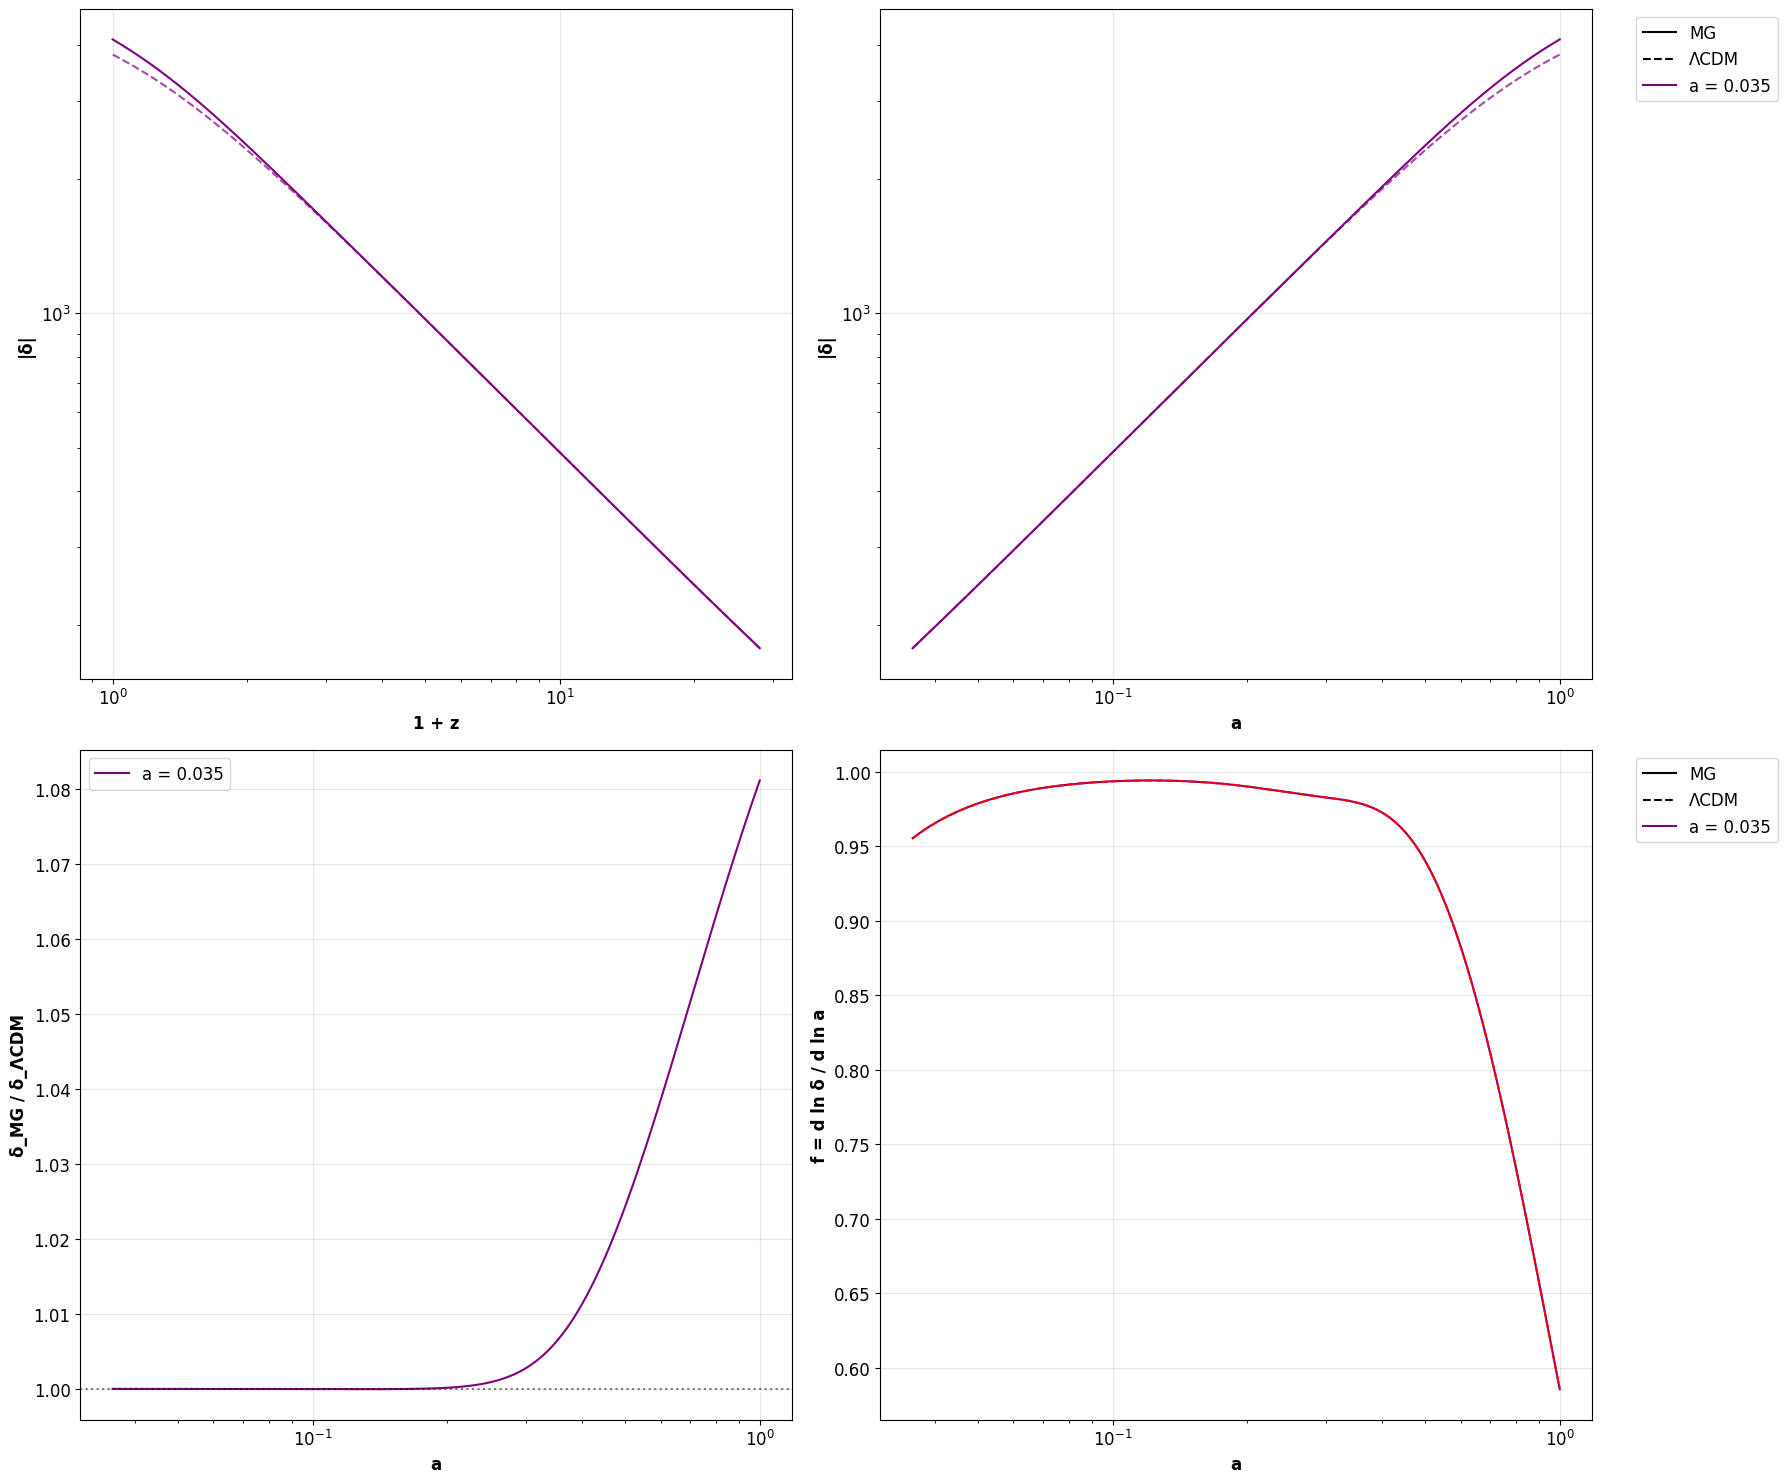

In [7]:
# Ejecutar análisis principal
print("=== Generando comparación principal ===")
fig1 = plot_delta_evolution_comparison(default_parameters, save_fig=False)
#print fiducial parameters
print("Parámetros fiduciales:")
fiducial_params = default_parameters[0]
print(f"Fiducial: a={fiducial_params['a']}, kh={fiducial_params['k h']}, h={fiducial_params['h']}, Ω_m={fiducial_params['Omega_m']}")

plt.show()

## 4. Estudio del espacio de parámetros
pequeño barrido en el espacio de parámetros y veo MG/LCDM. Quedó bastante feo el logarítmo

In [11]:
def plot_parameter_space_study():
    """
    Estudia el espacio de parámetros variando sistemáticamente cada uno
    """
    print("\n=== Iniciando estudio del espacio de parámetros ===")
    
    # Parámetros base
    base_params = {'a': 0.03, 'k h': 0.01, 'h': 0.68, 'Omega_m': 0.305}
    
    # Variaciones
    variations = {
        'k h': [0.001, 0.01, 0.1],
        'Omega_m': [0.25, 0.28, 0.305, 0.32, 0.35],
        'a': [0.03, .035]
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 15))
    
    for idx, (param_name, values) in enumerate(variations.items()):
        print(f"Variando {param_name}...")
        # Usar colores discretos en lugar de viridis continuo
        colors_discrete = ['blue', 'orange', 'green', 'red', 'purple']
        
        for i, value in enumerate(values):
            params = base_params.copy()
            params[param_name] = value
            
            # Crear solver
            k = params['k h'] / params['h']
            z_ini = int(1/params['a'] - 1)
            solver = DeltaSolver(Om_m_0=params['Omega_m'], z_0=z_ini, k=k)
            
            try:
                a_mg, delta_mg, _ = solver.solve_delta_mg(500)
                a_lcdm, delta_lcdm, _ = solver.solve_delta_lcdm(500)
                
                # Calcular ratio
                delta_mg_interp = np.interp(a_lcdm, a_mg, delta_mg)
                ratio = delta_mg_interp / delta_lcdm
                
                color = colors_discrete[i % len(colors_discrete)]
                axes[idx].plot(a_lcdm, ratio, color=color, 
                             label=f'{param_name} = {value}')
                
                print(f"  ✓ {param_name} = {value}")
                
            except Exception as e:
                print(f"  ✗ Error con {param_name} = {value}: {e}")
                continue
        
        axes[idx].set_xlabel('Factor de escala (a)')
        axes[idx].set_ylabel('δ_MG / δ_ΛCDM')
        axes[idx].set_title(f'Variación de {param_name}')
        axes[idx].axhline(y=1, color='black', linestyle=':', alpha=0.5)
        axes[idx].legend()
        axes[idx].set_xscale('log')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('/home/pedrorozin/scripts/parameter_space_study.png', 
    #            dpi=300, bbox_inches='tight')
    # print(f"Figura guardada en: /home/pedrorozin/scripts/parameter_space_study.png")
    return fig


=== Iniciando estudio del espacio de parámetros ===
Variando k h...
  ✓ k h = 0.001
  ✓ k h = 0.01
  ✓ k h = 0.1
Variando Omega_m...
  ✓ Omega_m = 0.25
  ✓ Omega_m = 0.28
  ✓ Omega_m = 0.305
  ✓ Omega_m = 0.32
  ✓ Omega_m = 0.35
Variando a...
  ✓ a = 0.03
  ✓ a = 0.035


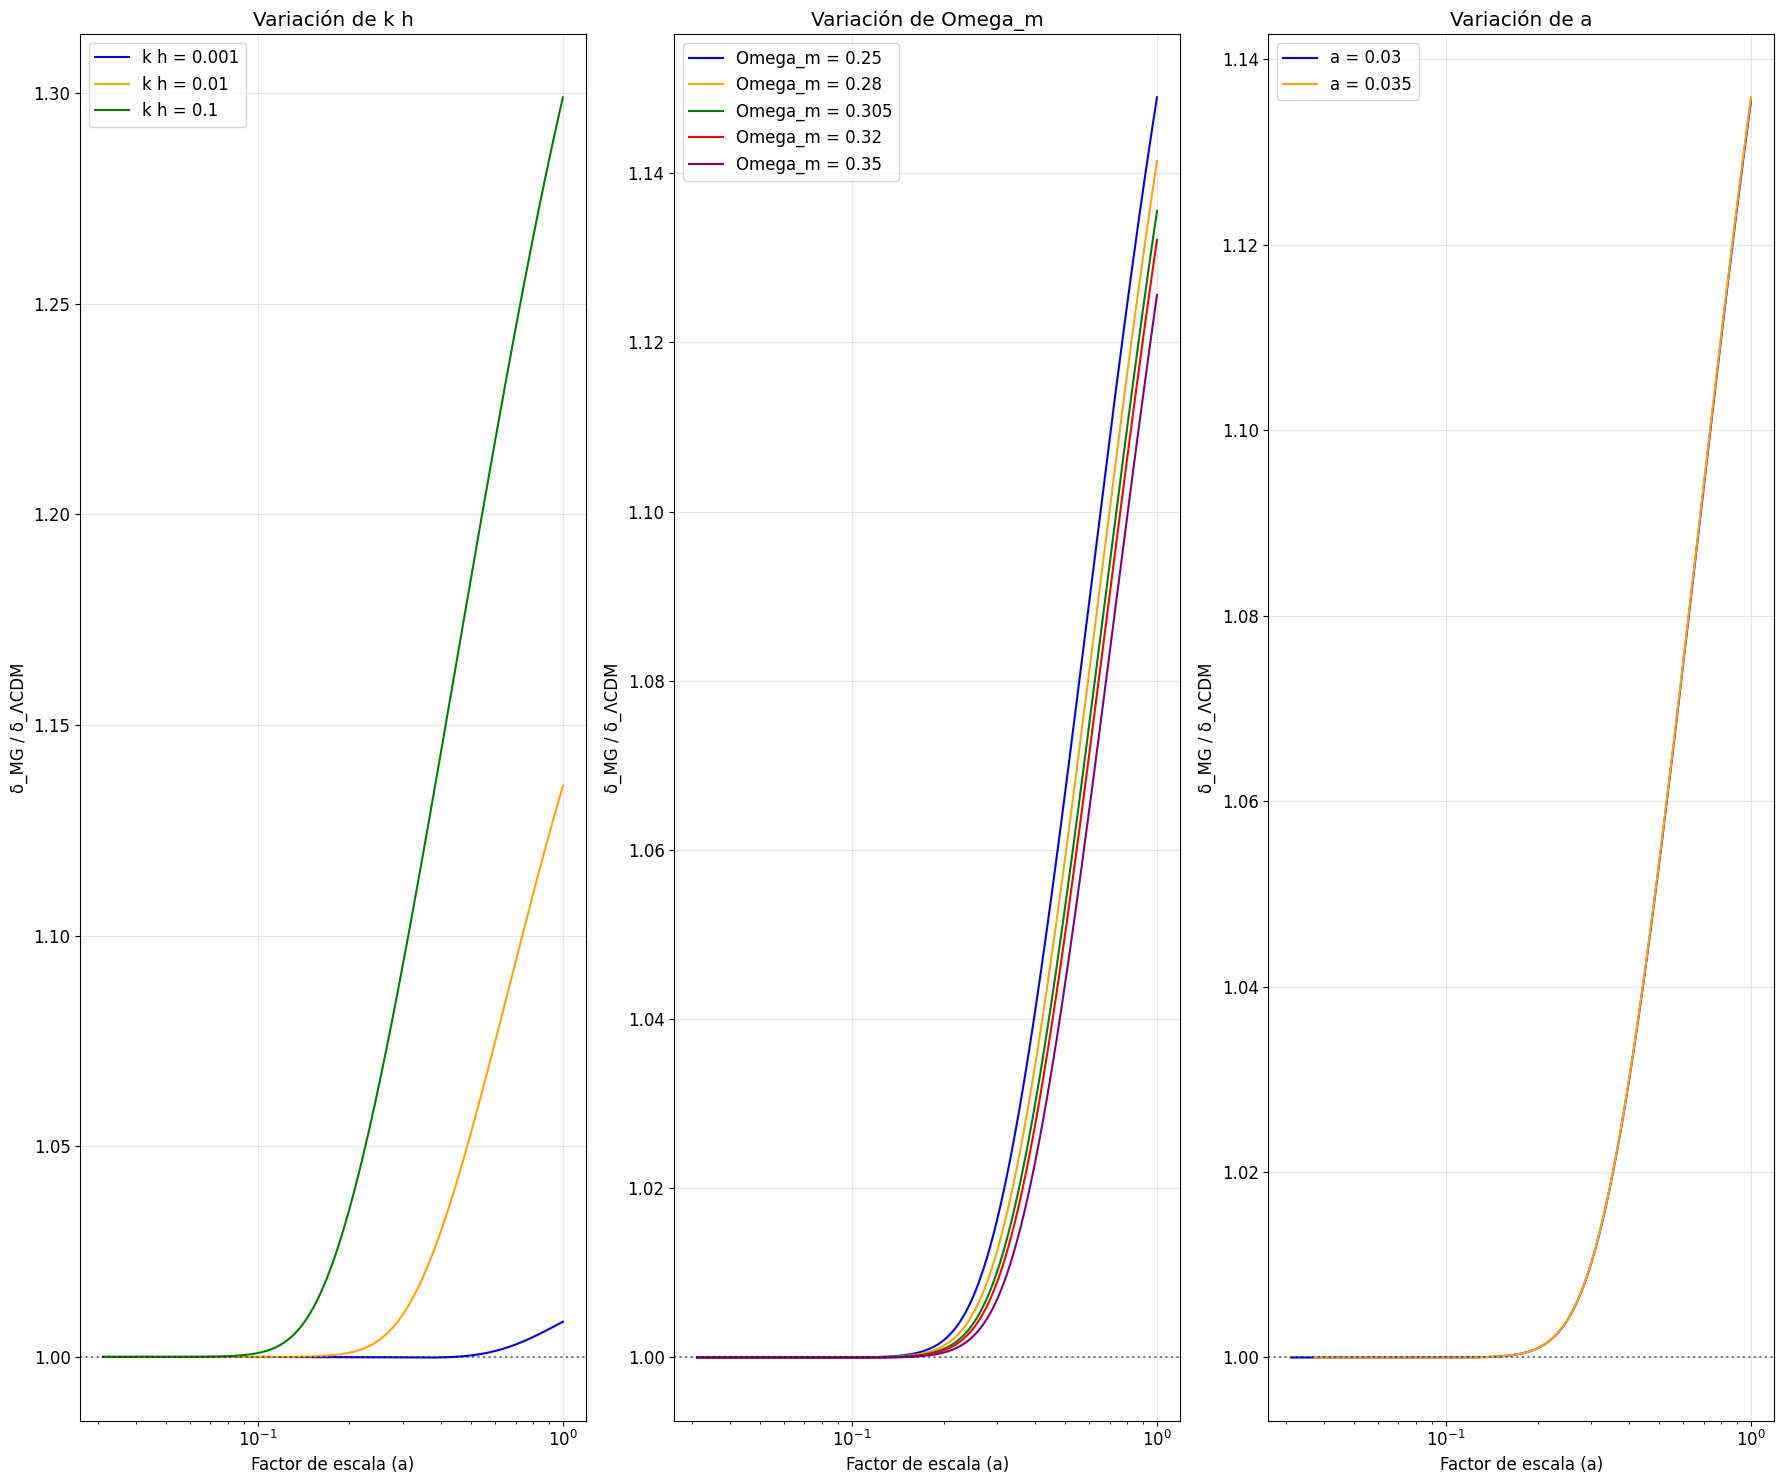

In [12]:
# Ejecutar estudio del espacio de parámetros
fig2 = plot_parameter_space_study()
plt.show()

## 5. Análisis con parámetros personalizados 

Definir conjuntos específicos

In [7]:
# Definir parámetros personalizados
custom_params = [
    {'a': 0.03, 'k h': 0.05, 'h': 0.68, 'Omega_m': 0.3, 'label': 'MG'}
    # {'a': 0.03, 'k h': 0.02, 'h': 0.68, 'Omega_m': 0.31, 'label': 'Custom 2'},
]

# Mostrar parámetros personalizados
print("Parámetros personalizados:")
for i, params in enumerate(custom_params):
    print(f"{i+1}. {params['label']}: a={params['a']}, kh={params['k h']}, h={params['h']}, Ω_m={params['Omega_m']}")

Parámetros personalizados:
1. MG: a=0.03, kh=0.05, h=0.68, Ω_m=0.3


=== Generando plots con parámetros personalizados ===


/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:56: RuntimeWarning: divide by zero encountered in scalar divide
  return (r + b) * ((r + b)**2 - 2*b) / (4*b*r)
/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:65: RuntimeWarning: invalid value encountered in scalar multiply
  f2 = -(v*x*g - x*y + 4*y - 2*y*v) / denom
/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:66: RuntimeWarning: invalid value encountered in scalar multiply
  f3 = -v * (x*g + 4 - 2*v) / denom
/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:68: RuntimeWarning: invalid value encountered in scalar multiply
  f5 = -r * g * x / denom


KeyboardInterrupt: 

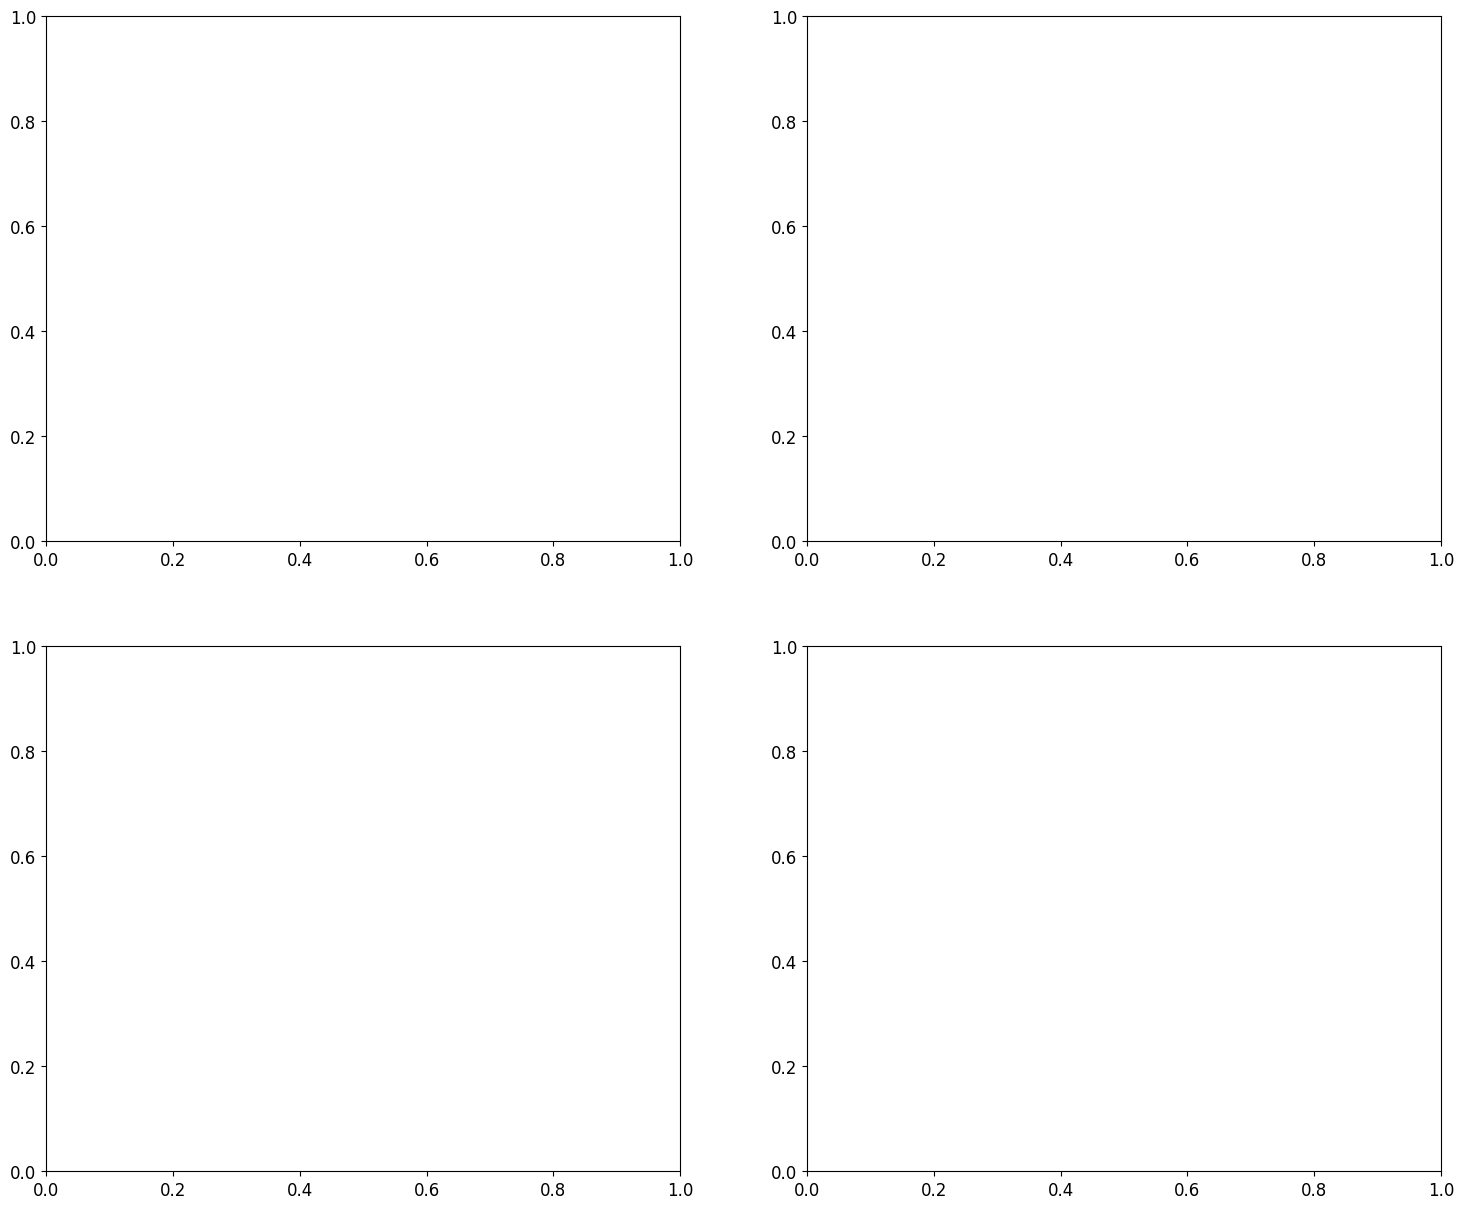

In [8]:
# Ejecutar análisis con parámetros personalizados
print("=== Generando plots con parámetros personalizados ===")
fig3 = plot_delta_evolution_comparison(custom_params, save_fig=False)
plt.show()

## 6. Análisis individual de un conjunto específico

Para analizar en detalle un conjunto específico de parámetros. Esto no está bonito.

In [10]:
def analyze_single_parameter_set(a_ini, kh, h, Om_m, b=0.1, label="Single Analysis"):
    """
    Análisis detallado de un conjunto específico de parámetros
    """
    print(f"\n=== Análisis detallado: {label} ===")
    print(f"Parámetros: a={a_ini}, kh={kh}, h={h}, Ω_m={Om_m}, b={b}")
    
    # Crear solver
    k = kh / h
    z_ini = int(1/a_ini - 1)
    solver = DeltaSolver(Om_m_0=Om_m, z_0=z_ini, k=k, b=b)
    
    try:
        # Resolver ambos modelos
        a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg(1000)
        a_lcdm, delta_lcdm, delta_p_lcdm = solver.solve_delta_lcdm(1000)
        
        # Crear plots detallados
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Plot 1: Delta vs a
        axes[0,0].plot(a_mg, delta_mg, 'b-', label='MG', linewidth=2)
        axes[0,0].plot(a_lcdm, delta_lcdm, 'r--', label='ΛCDM', linewidth=2)
        axes[0,0].set_xlabel('Factor de escala (a)')
        axes[0,0].set_ylabel('δ')
        axes[0,0].set_title('Evolución de δ')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Plot 2: Delta' vs a
        axes[0,1].plot(a_mg, delta_p_mg, 'b-', label='MG', linewidth=2)
        axes[0,1].plot(a_lcdm, delta_p_lcdm, 'r--', label='ΛCDM', linewidth=2)
        axes[0,1].set_xlabel('Factor de escala (a)')
        axes[0,1].set_ylabel("δ'")
        axes[0,1].set_title("Evolución de δ'")
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Plot 3: Ratio
        delta_mg_interp = np.interp(a_lcdm, a_mg, delta_mg)
        ratio = delta_mg_interp / delta_lcdm
        axes[0,2].plot(a_lcdm, ratio, 'g-', linewidth=2)
        axes[0,2].axhline(y=1, color='black', linestyle=':', alpha=0.5)
        axes[0,2].set_xlabel('Factor de escala (a)')
        axes[0,2].set_ylabel('δ_MG / δ_ΛCDM')
        axes[0,2].set_title('Ratio MG/ΛCDM')
        axes[0,2].grid(True, alpha=0.3)
        
        # Plot 4: Growth rate
        f_mg = np.gradient(np.log(np.abs(delta_mg)), np.log(a_mg))
        f_lcdm = np.gradient(np.log(np.abs(delta_lcdm)), np.log(a_lcdm))
        axes[1,0].plot(a_mg, f_mg, 'b-', label='MG', linewidth=2)
        axes[1,0].plot(a_lcdm, f_lcdm, 'r--', label='ΛCDM', linewidth=2)
        axes[1,0].set_xlabel('Factor de escala (a)')
        axes[1,0].set_ylabel('f = d ln δ / d ln a')
        axes[1,0].set_title('Tasa de crecimiento')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Plot 5: Diferencia porcentual
        percent_diff = 100 * (delta_mg_interp - delta_lcdm) / delta_lcdm
        axes[1,1].plot(a_lcdm, percent_diff, 'purple', linewidth=2)
        axes[1,1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
        axes[1,1].set_xlabel('Factor de escala (a)')
        axes[1,1].set_ylabel('Diferencia % (MG-ΛCDM)/ΛCDM')
        axes[1,1].set_title('Diferencia porcentual')
        axes[1,1].grid(True, alpha=0.3)
        
        # Plot 6: Phase space
        axes[1,2].plot(delta_mg, delta_p_mg, 'b-', label='MG', linewidth=2)
        axes[1,2].plot(delta_lcdm, delta_p_lcdm, 'r--', label='ΛCDM', linewidth=2)
        axes[1,2].set_xlabel('δ')
        axes[1,2].set_ylabel("δ'")
        axes[1,2].set_title('Espacio de fases')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Imprimir estadísticas
        print(f"✓ Análisis completado para {label}")
        print(f"  - Ratio final δ_MG/δ_ΛCDM: {ratio[-1]:.4f}")
        print(f"  - Diferencia porcentual final: {percent_diff[-1]:.2f}%")
        print(f"  - Tasa de crecimiento final MG: {f_mg[-1]:.4f}")
        print(f"  - Tasa de crecimiento final ΛCDM: {f_lcdm[-1]:.4f}")
        
        return fig, {'ratio': ratio, 'percent_diff': percent_diff, 'f_mg': f_mg, 'f_lcdm': f_lcdm}
        
    except Exception as e:
        print(f"✗ Error en análisis: {e}")
        return None, None

In [11]:
# Ejemplo de análisis detallado
fig_detailed, stats = analyze_single_parameter_set(
    a_ini=0.03, kh=0.01, h=0.68, Om_m=0.305, b=0.0001, label="Caso Fiducial Detallado b=0.0001"
)
plt.show()


=== Análisis detallado: Caso Fiducial Detallado b=0.0001 ===
Parámetros: a=0.03, kh=0.01, h=0.68, Ω_m=0.305, b=0.0001
✗ Error en análisis: Values in `t_eval` are not within `t_span`.
